In [1]:
dirs = ["v1", "v2", "v2l2", "v3_swa", "v4_swa", "v5_swa"]
names = ["v1", "v2", "v2l2", "v3", "v4", "v5"]

In [13]:
# ==============================================================================
# PARAMETERS & CONFIGURATION (Modify these values for each file)
# ==============================================================================

def plot(dir, name):
    INPUT_FILE = dir + "/graphene_potential.out"    # Path to your raw data file    
    OUTPUT_DIR = "./plots/"                 # Directory where the PDF will save
    FILE_ID = name                         # Custom text label displayed on the plot

    # Colorbar normalization (Keep these identical across cells/files to compare them)
    VMIN = 0.0                             # Minimum energy value for color scale
    VMAX = 11                           # Maximum energy value for color scale
    nlabels = VMAX+1

    # ==============================================================================
    # PES MAP GENERATION PIPELINE
    # ==============================================================================
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print(f"--- Processing PES Map for: {INPUT_FILE} ---")

    # 1. Parse data from the file
    scan_positions = []
    scan_energies = []

    with open(INPUT_FILE, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 4:
                x, y, z, energy = map(float, parts[:4])
                scan_positions.append([x, y])
                scan_energies.append(energy)

    scan_positions = np.array(scan_positions)
    scan_energies = np.array(scan_energies)

    # Relativize energy baseline to start locally at 0
    scan_energies -= np.min(scan_energies)

    # 2. Establish dynamic bounding boxes with 5% padding
    # x_min, x_max = np.min(scan_positions[:, 0]), np.max(scan_positions[:, 0])
    # y_min, y_max = np.min(scan_positions[:, 1]), np.max(scan_positions[:, 1])
    x_min, x_max = -1.26, 0.6
    y_min, y_max = 0, 2.1

    pad_x = (x_max - x_min) * 0.05 if x_max > x_min else 0.5
    pad_y = (y_max - y_min) * 0.05 if y_max > y_min else 0.5

    # Generate a dense grid mesh for interpolation
    grid_x, grid_y = np.mgrid[(x_min - pad_x):(x_max + pad_x):300j, 
                            (y_min - pad_y):(y_max + pad_y):300j]

    grid_z = griddata(scan_positions, scan_energies, (grid_x, grid_y), method='linear')*1000

    # 3. Plot Setup
    fig, ax = plt.subplots(figsize=(9, 8))

    # Fix the scale transitions by distributing contours evenly between VMIN and VMAX
    levels = np.linspace(VMIN, VMAX, 61)
    contour = ax.contourf(grid_x, grid_y, grid_z, levels=levels, cmap='viridis', extend="max")

    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('Relative Energy [meV]', rotation=270, labelpad=20, fontsize=18)
    colorbar_ticks = np.linspace(VMIN, VMAX, nlabels, endpoint=True)
    cbar.set_ticks(colorbar_ticks)

    # Scatter evaluated grid data
    ax.scatter(scan_positions[:, 0], scan_positions[:, 1], 
            color='white', s=10, edgecolor='black', linewidths=0.4, label='Evaluated Data Points')

    # 4. Specific Stacking Labels
    # Atop (AA) Stacking at the origin (0,0)
    ax.annotate('Atop (AA)', xy=(0.0, 0.0), xytext=(-0.8, 0),
                arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
                fontsize=18, fontweight='bold', 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="gray"))

    # Bernal (AB) Stacking at (2.46 / 6, 0)
    a = 2.46
    bernal_x = 0
    bernal_y = a * np.sqrt(3)/3
    ax.annotate('Bernal (AB)', xy=(bernal_x, bernal_y), xytext=(bernal_x + 0.2, bernal_y+0.2),
                arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
                fontsize=18, fontweight='bold', 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="gray"))

    # 5. Persistent Canvas Version Marker (Top Left corner of axes frame)
    ax.text(0.1, 0.1, FILE_ID, transform=ax.transAxes, fontsize=18,
            fontweight='bold', verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle="square,pad=0.4", fc="lightgray", alpha=0.8, ec="black"))

    # 6. Dimensions and Cleanups
    ax.set_xlabel(r'X-Translation $\mathrm{[\AA]}$')
    ax.set_ylabel(r'Y-Translation $\mathrm{[\AA]}$')
    # ax.set_title('Bernal Bilayer Graphene Potential Energy Surface', fontsize=13, pad=15)
    ax.legend(loc='upper right', framealpha=0.9, fontsize = 18)
    ax.axis('equal')

    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)

    # Save to PDF outside notebook environment
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plot_file = os.path.join(OUTPUT_DIR, f"graphene_potential_map_{FILE_ID}.pdf")
    plt.tight_layout()
    plt.savefig(plot_file)

    # Explicitly call show to render cleanly inside the Jupyter Notebook window
    plt.show()
    plt.close()
    print(f"Success! Map rendering generated and saved to '{plot_file}'")

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


--- Processing PES Map for: v1/graphene_potential.out ---


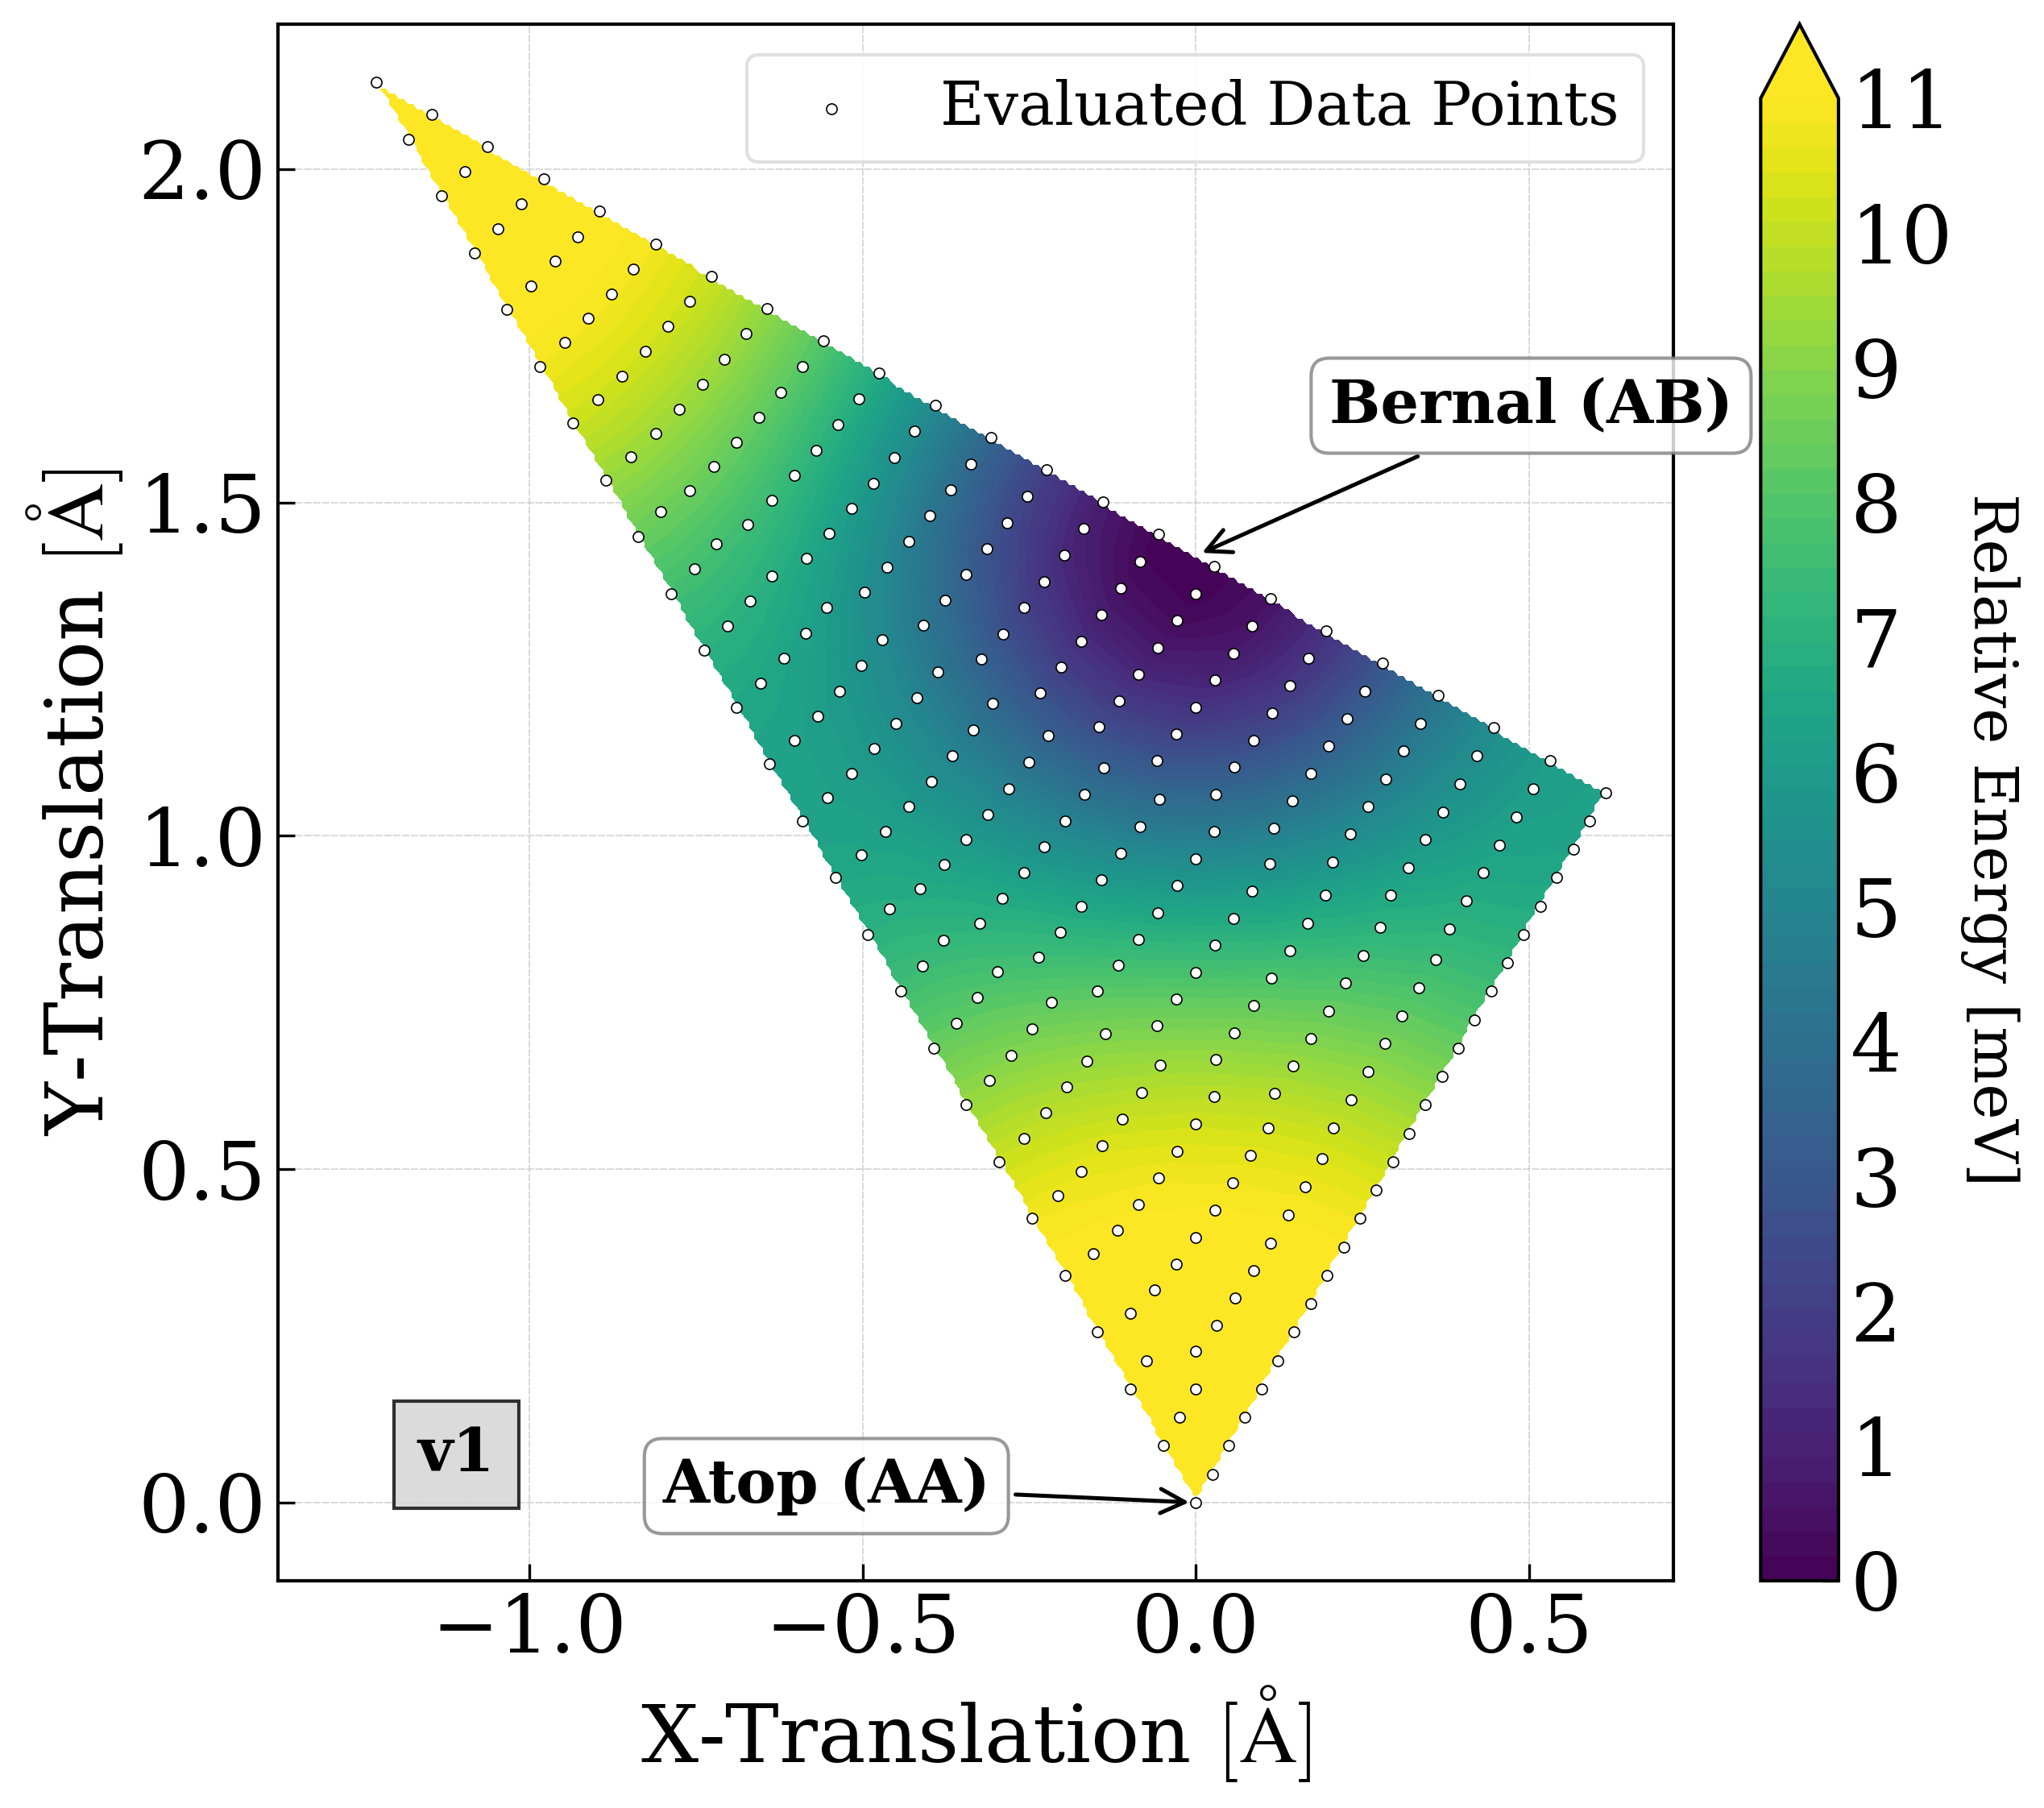

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Success! Map rendering generated and saved to './plots/graphene_potential_map_v1.pdf'
--- Processing PES Map for: v2/graphene_potential.out ---


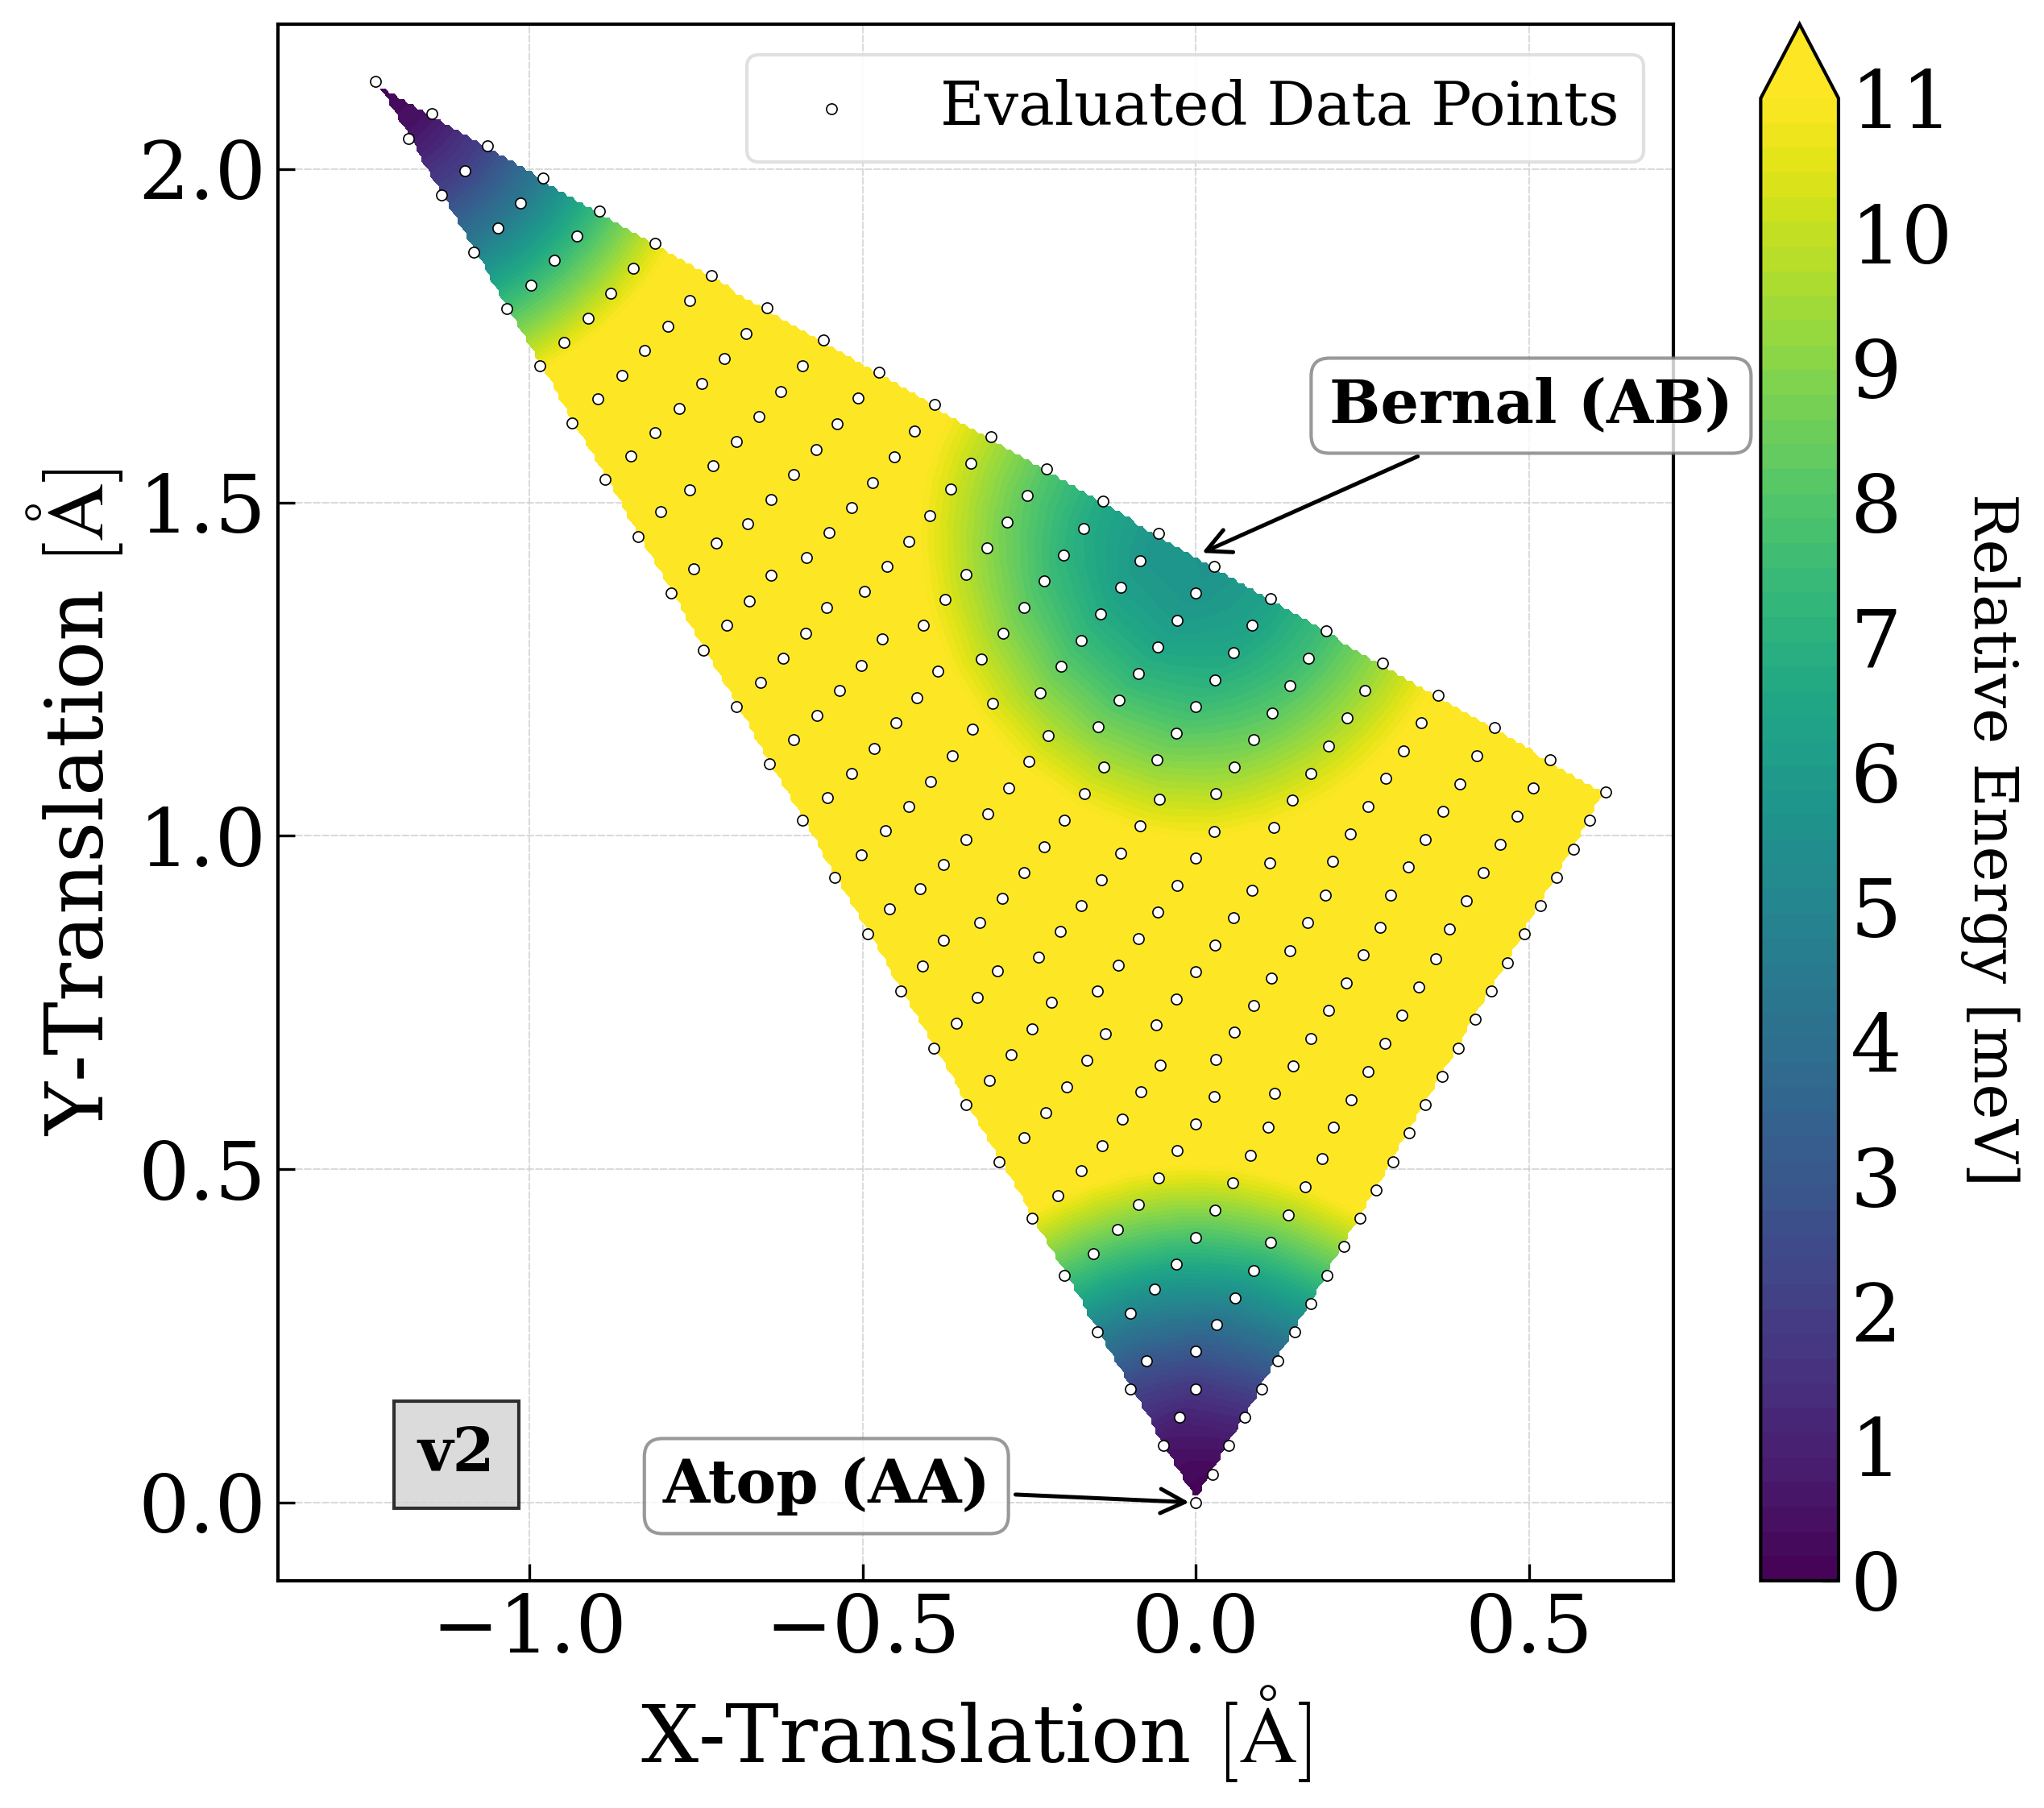

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Success! Map rendering generated and saved to './plots/graphene_potential_map_v2.pdf'
--- Processing PES Map for: v2l2/graphene_potential.out ---


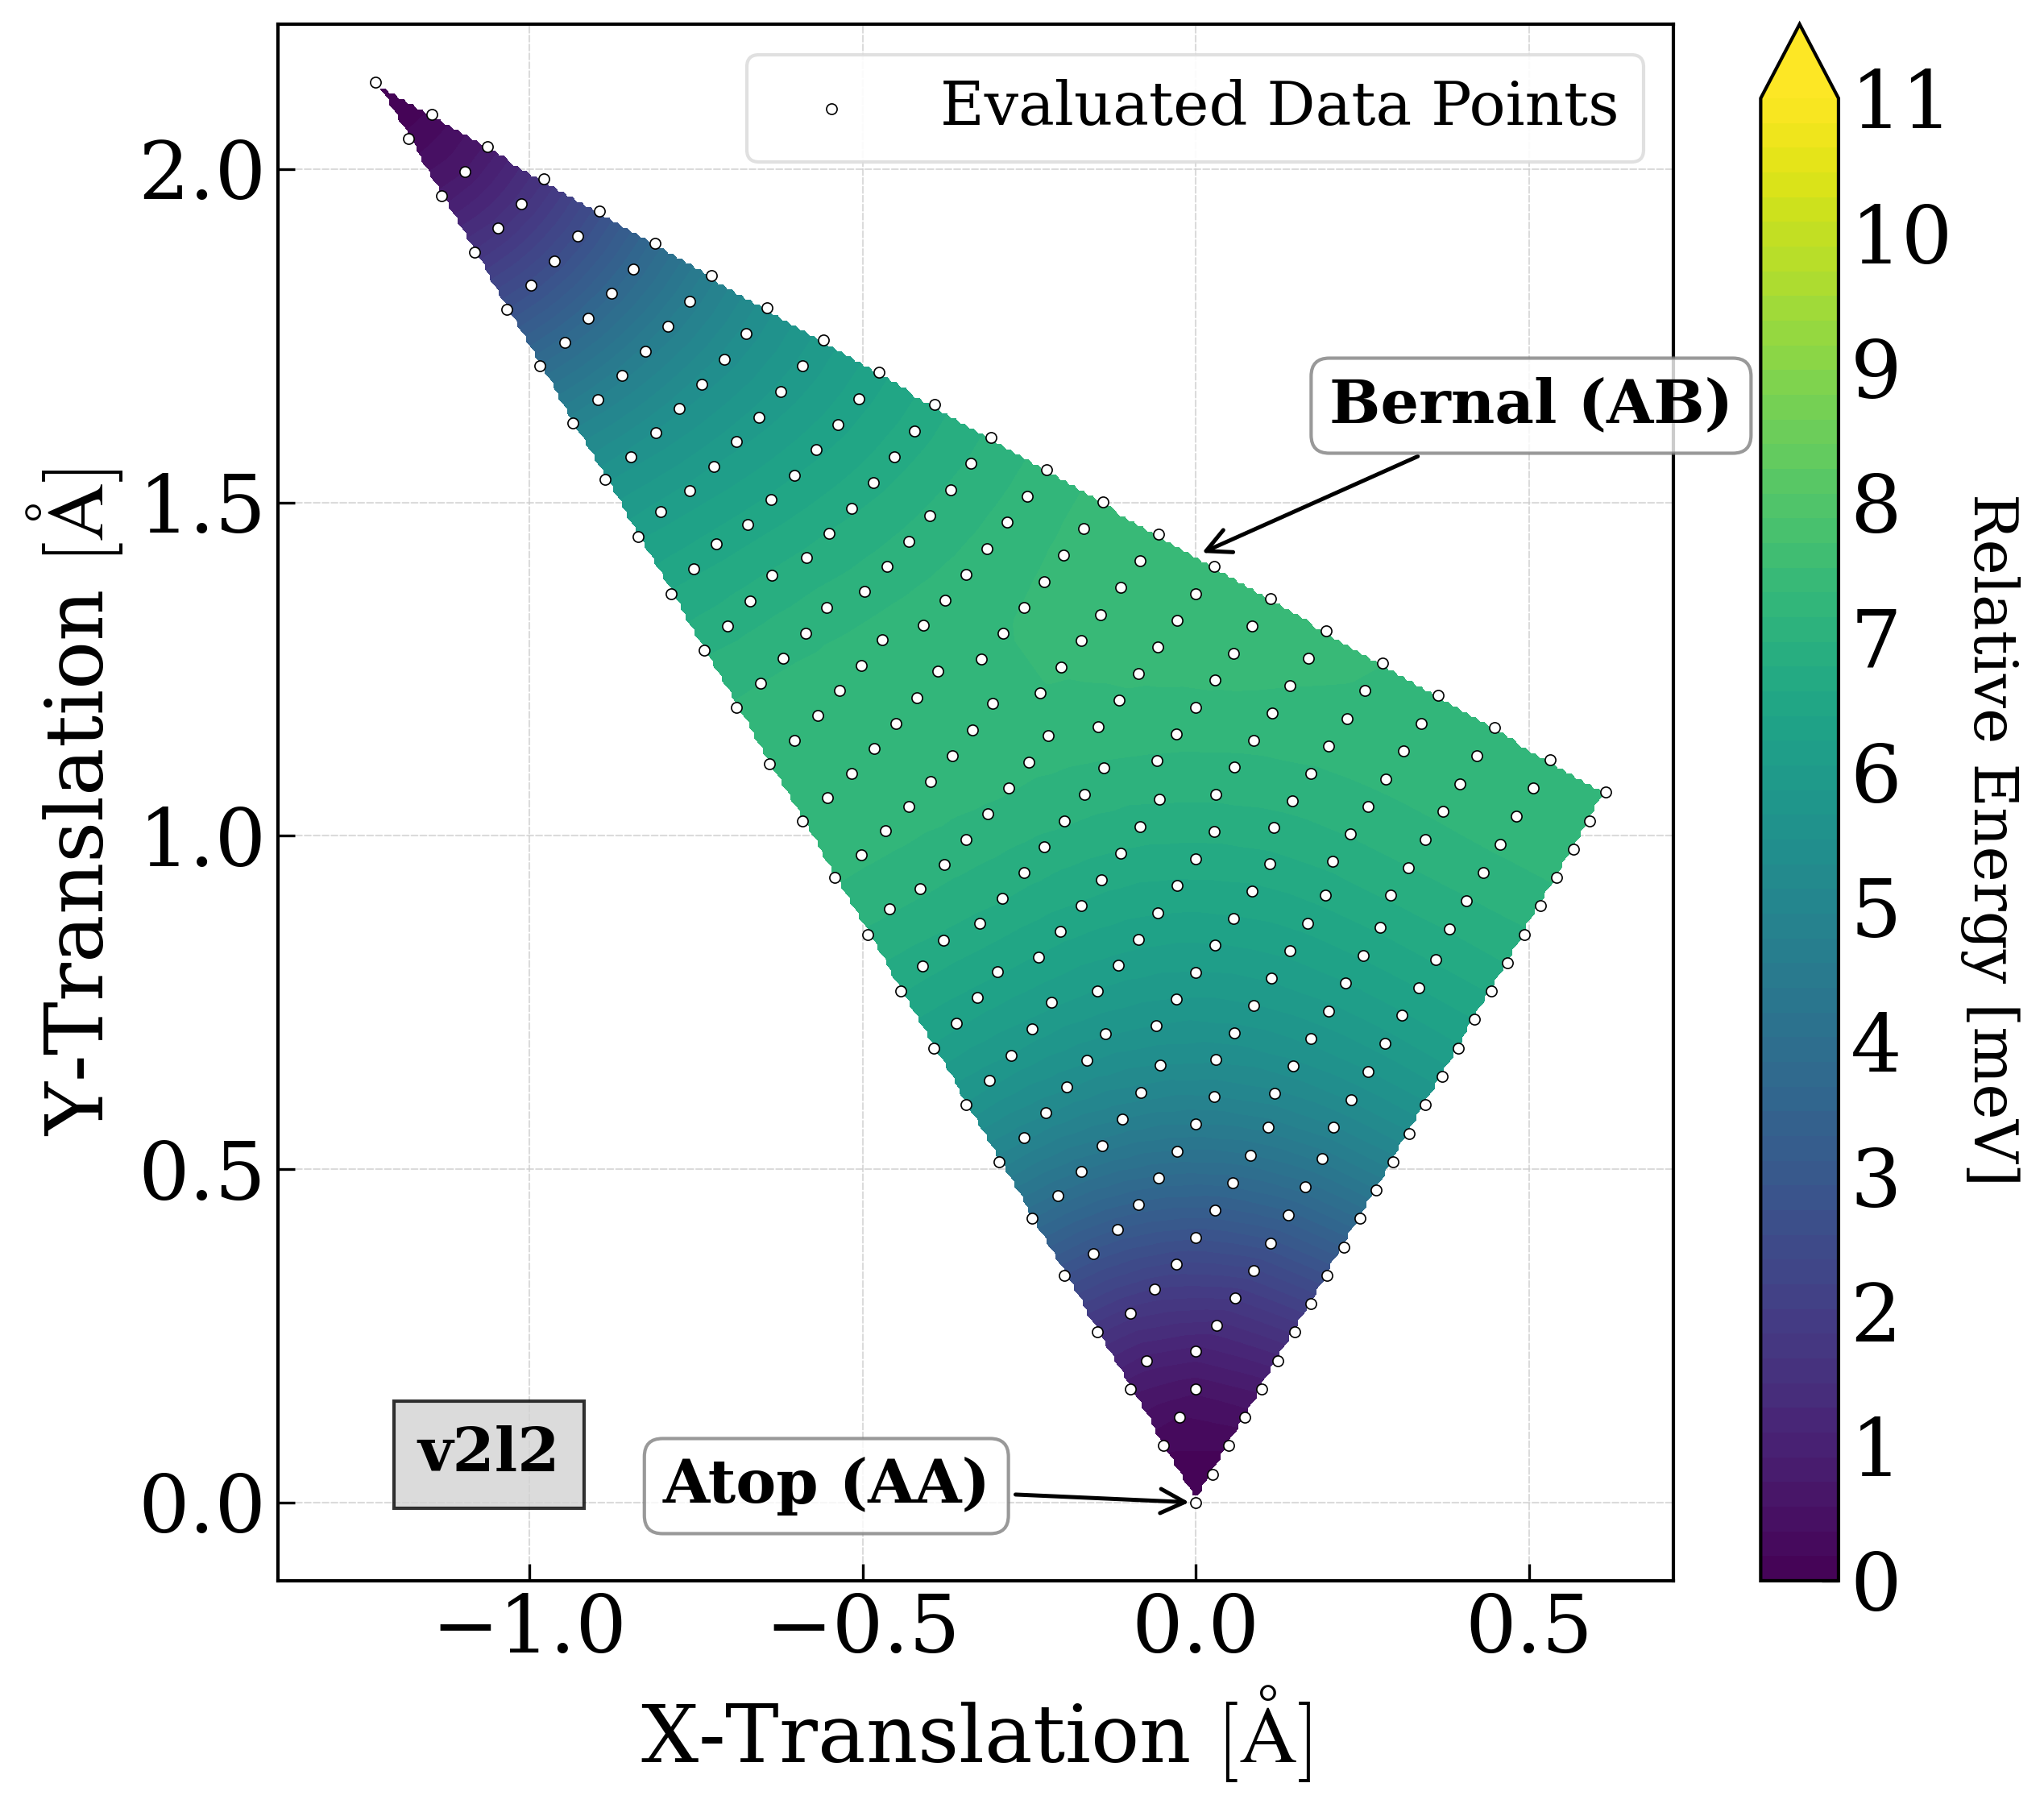

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Success! Map rendering generated and saved to './plots/graphene_potential_map_v2l2.pdf'
--- Processing PES Map for: v3_swa/graphene_potential.out ---


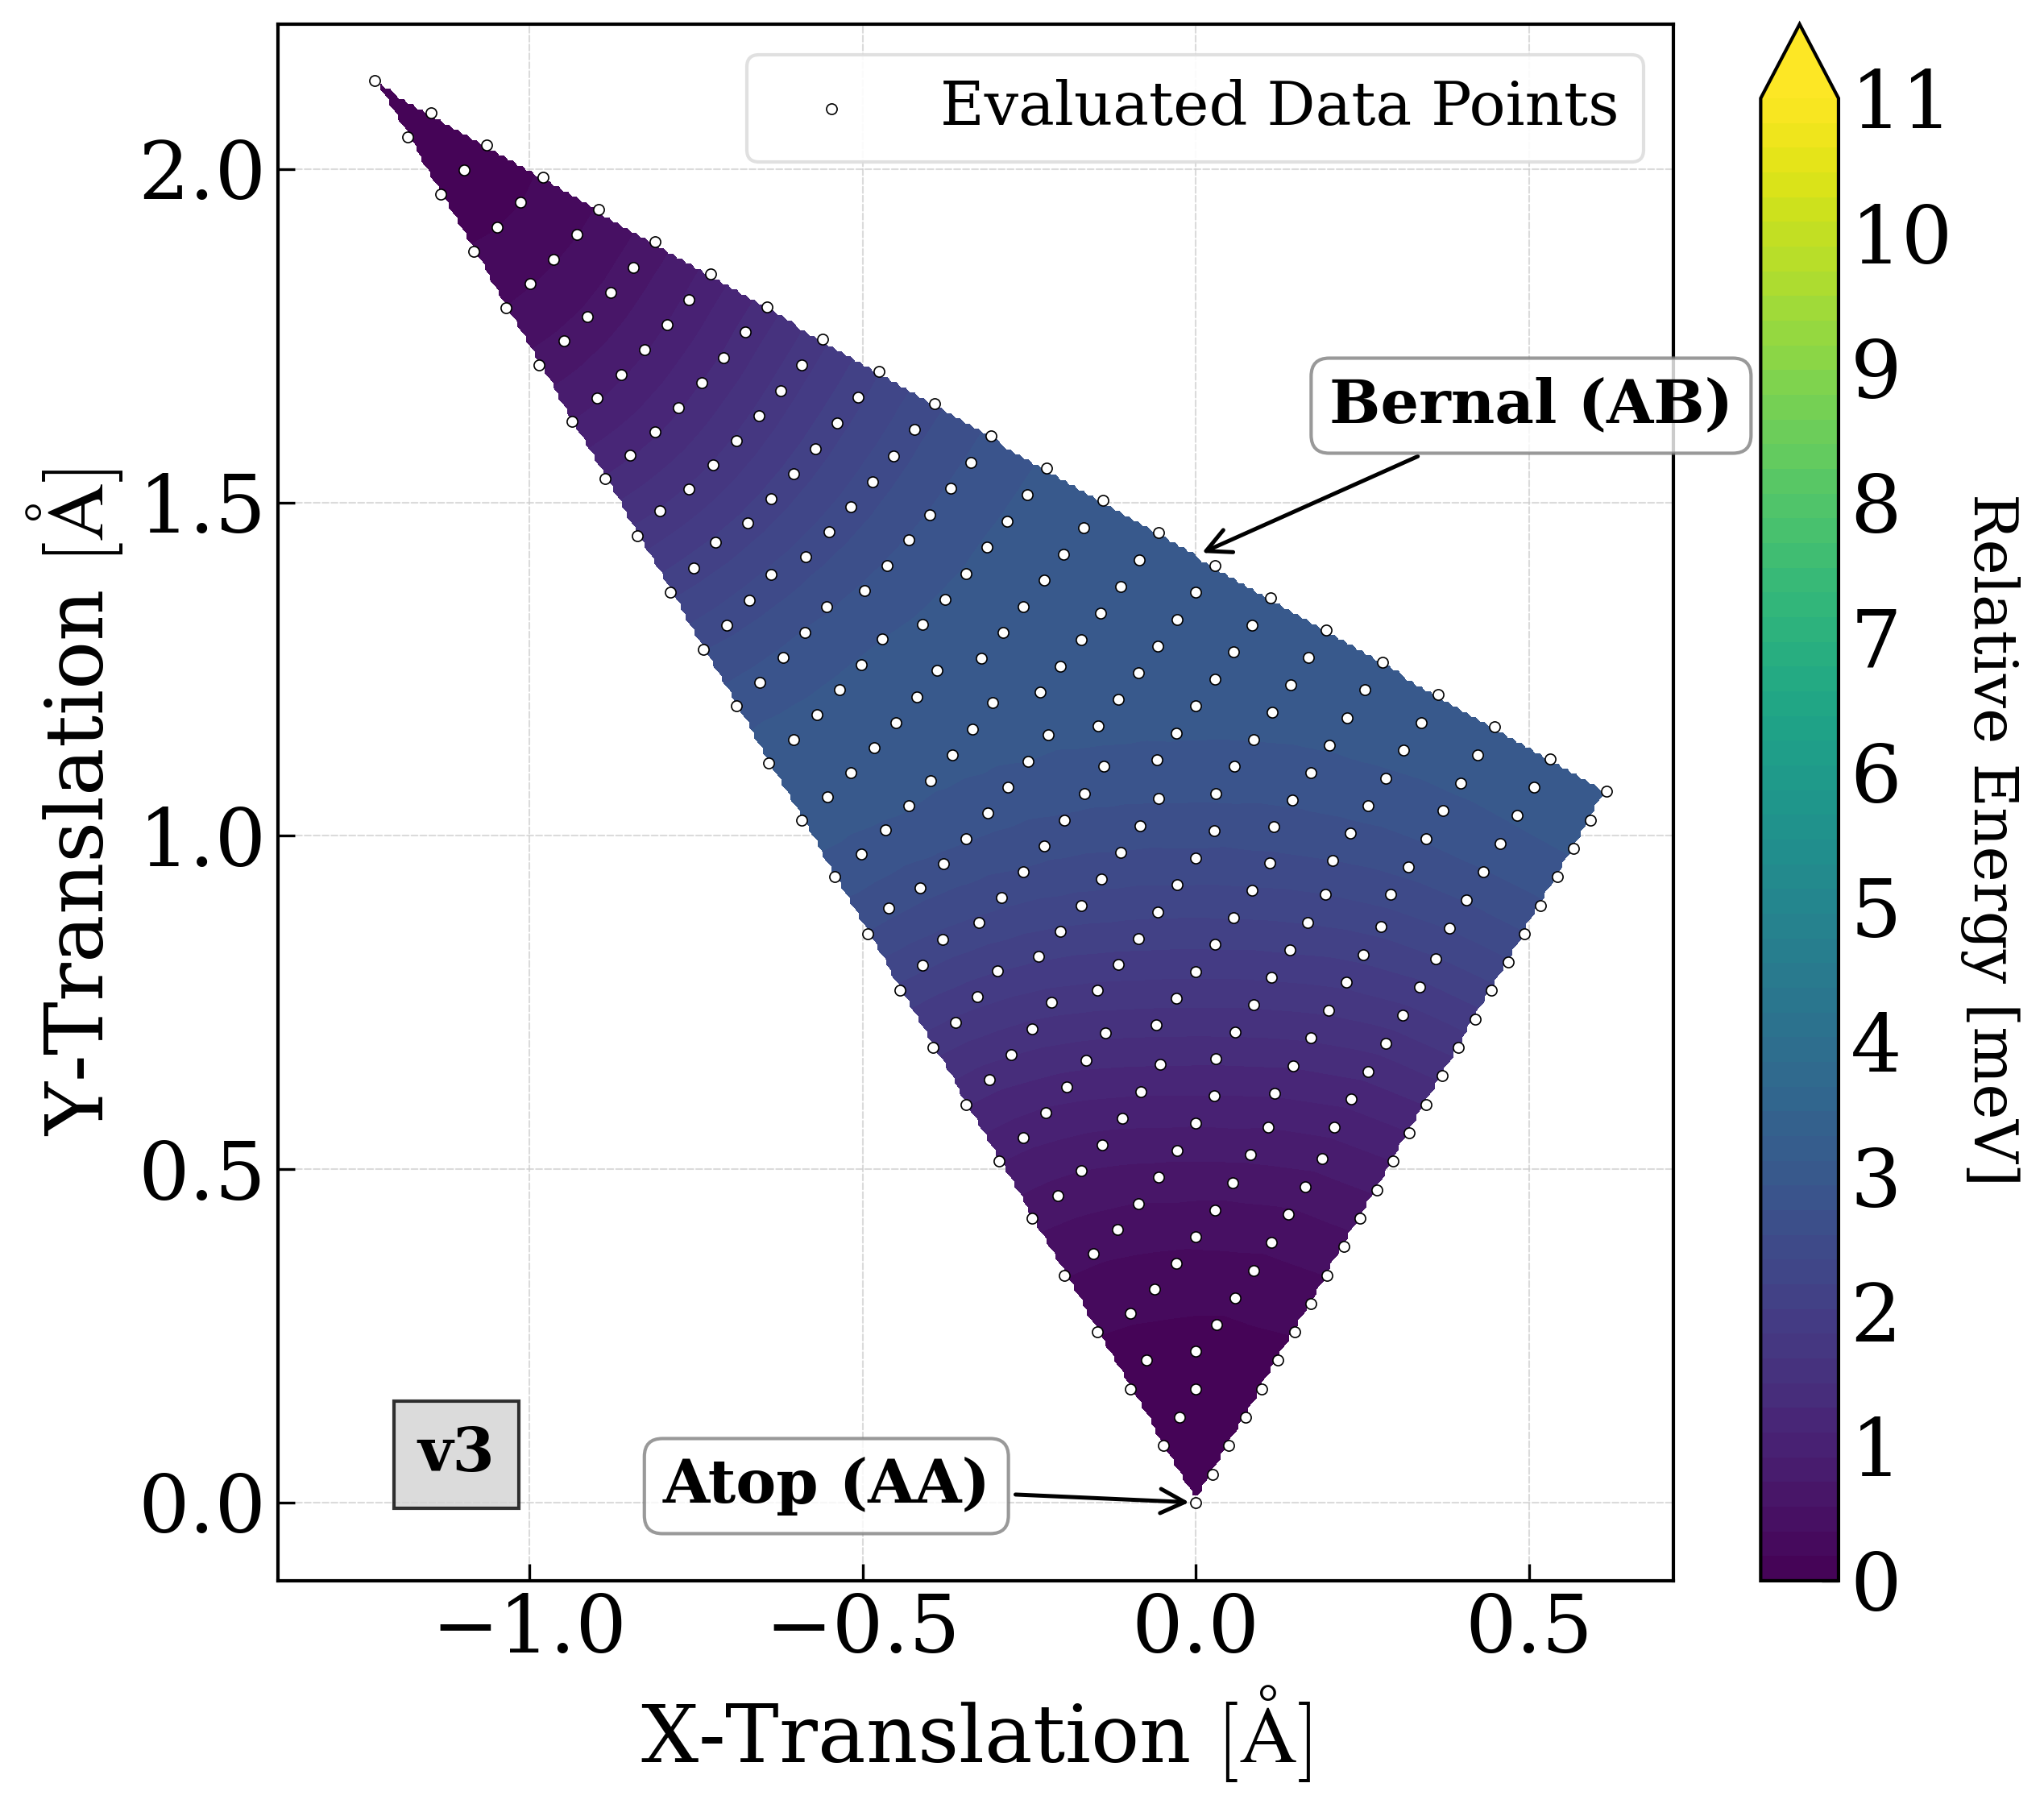

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Success! Map rendering generated and saved to './plots/graphene_potential_map_v3.pdf'
--- Processing PES Map for: v4_swa/graphene_potential.out ---


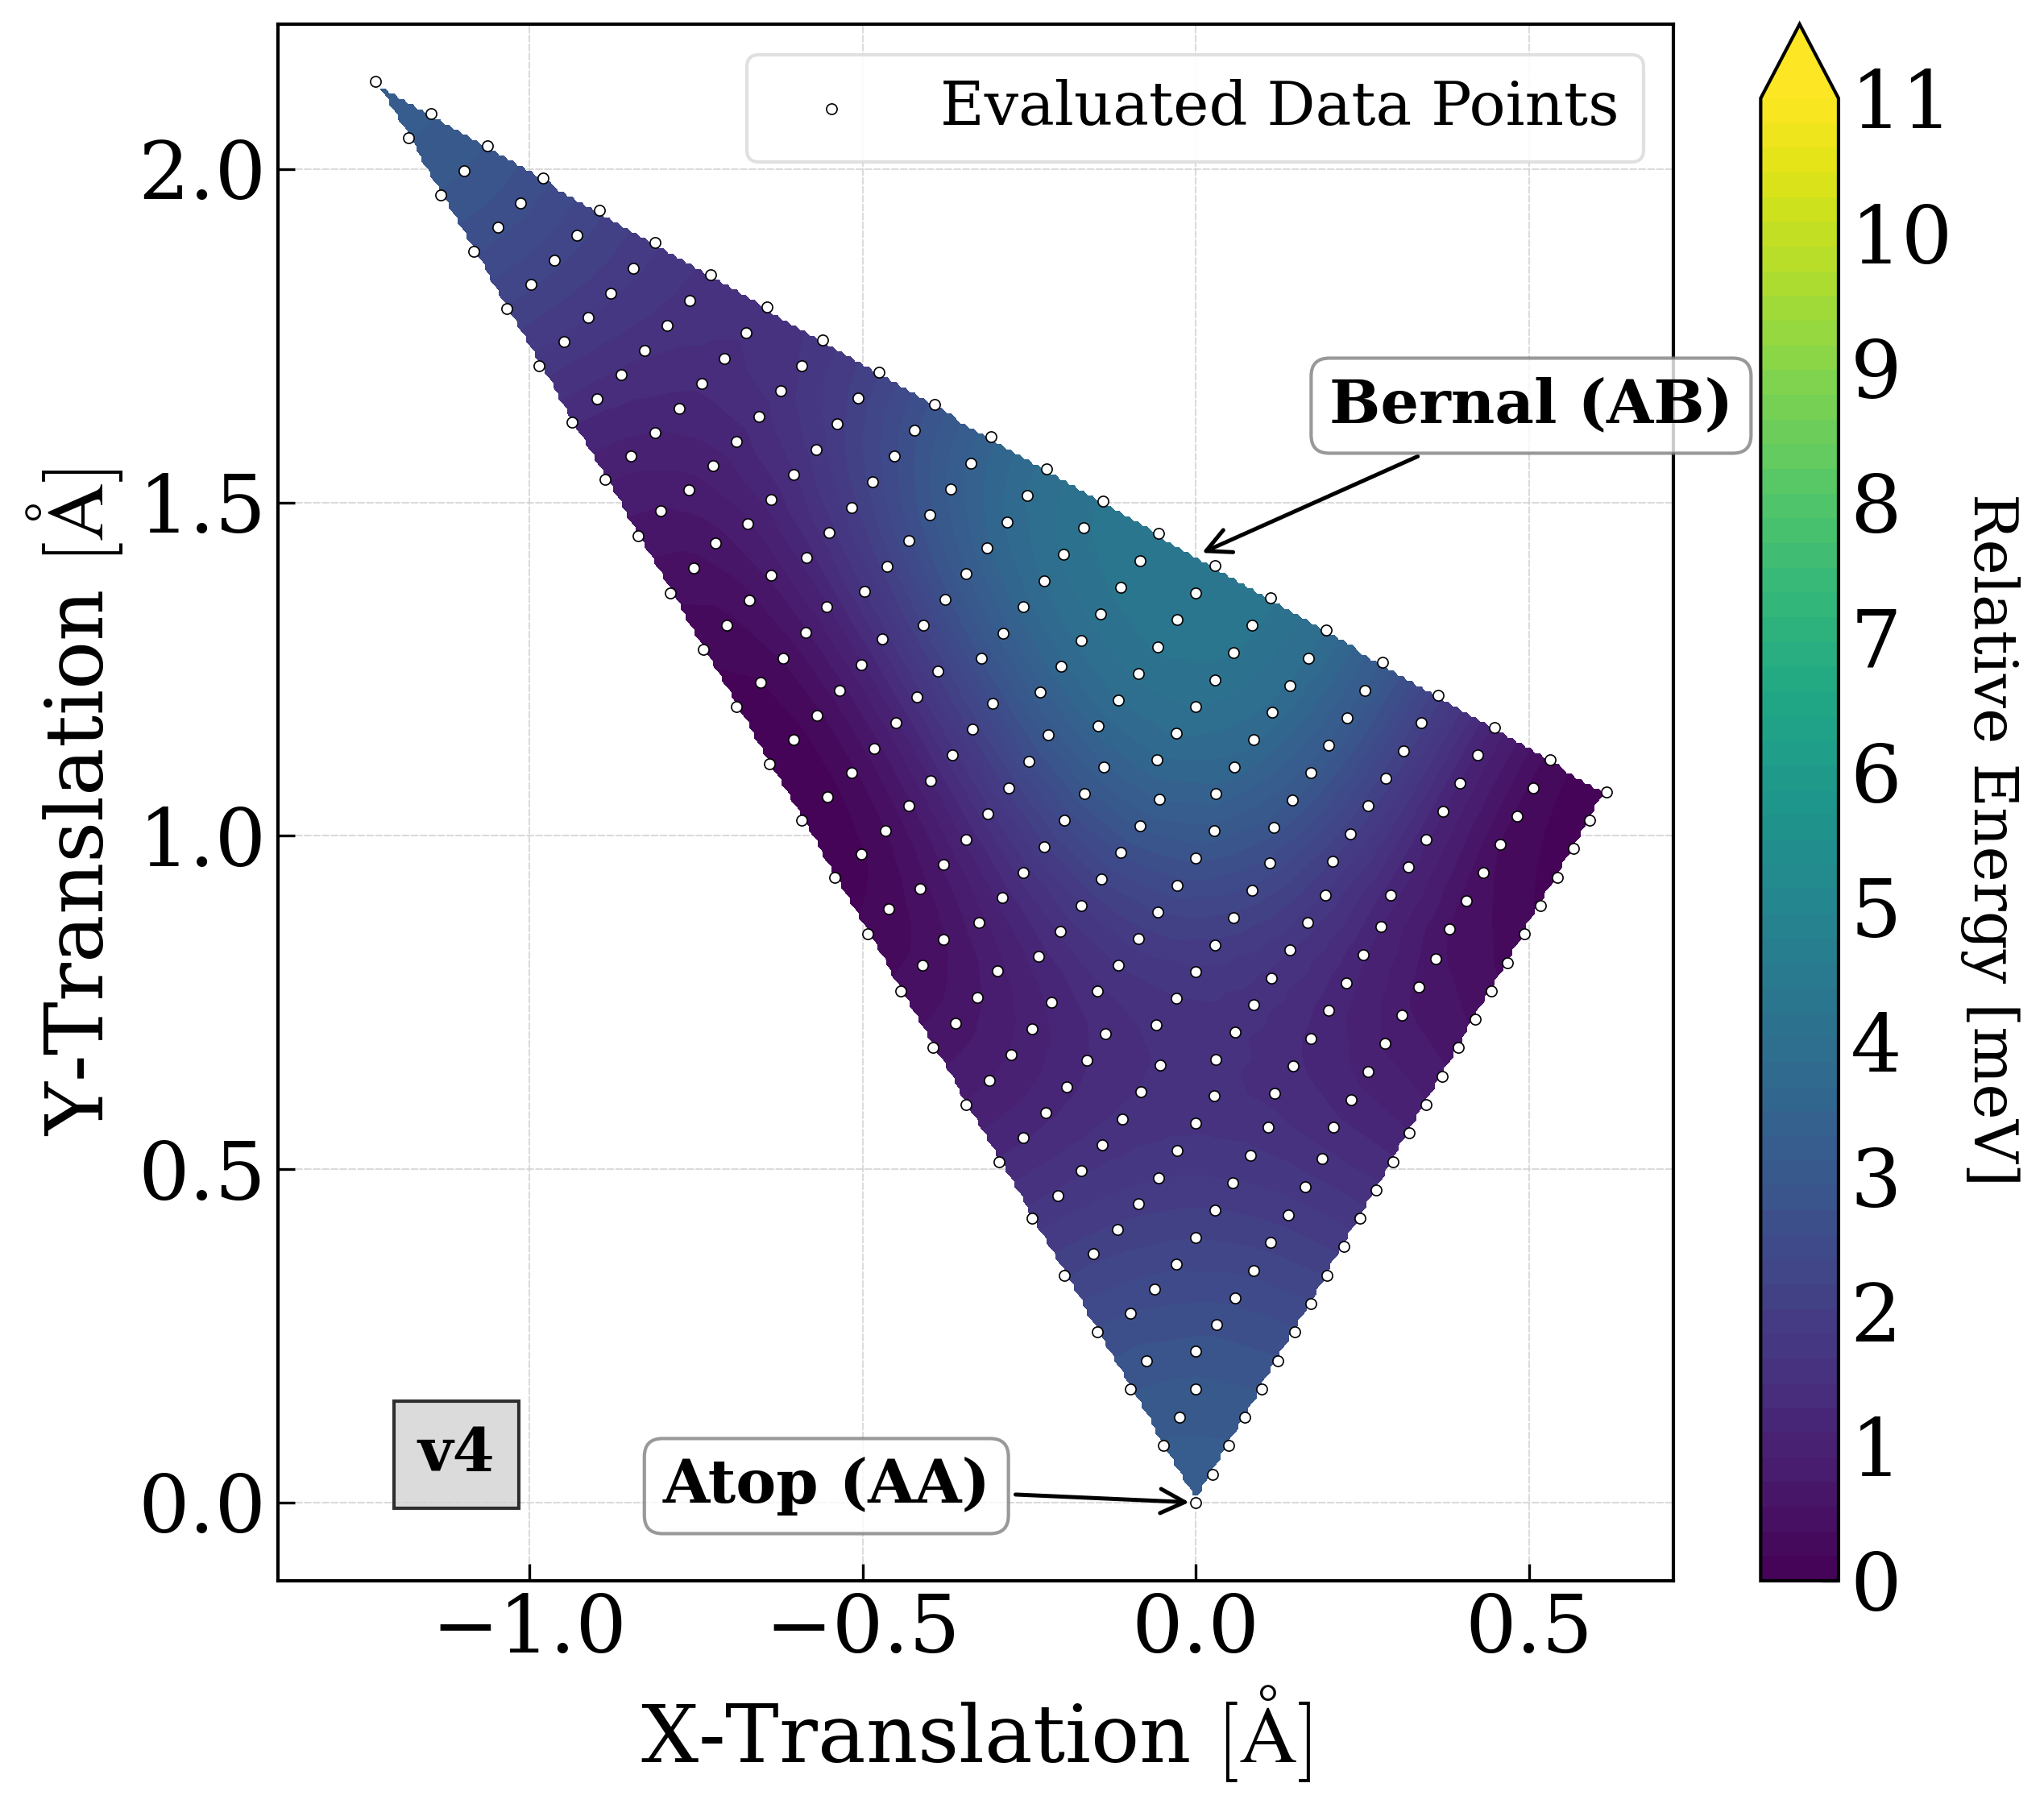

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Success! Map rendering generated and saved to './plots/graphene_potential_map_v4.pdf'
--- Processing PES Map for: v5_swa/graphene_potential.out ---


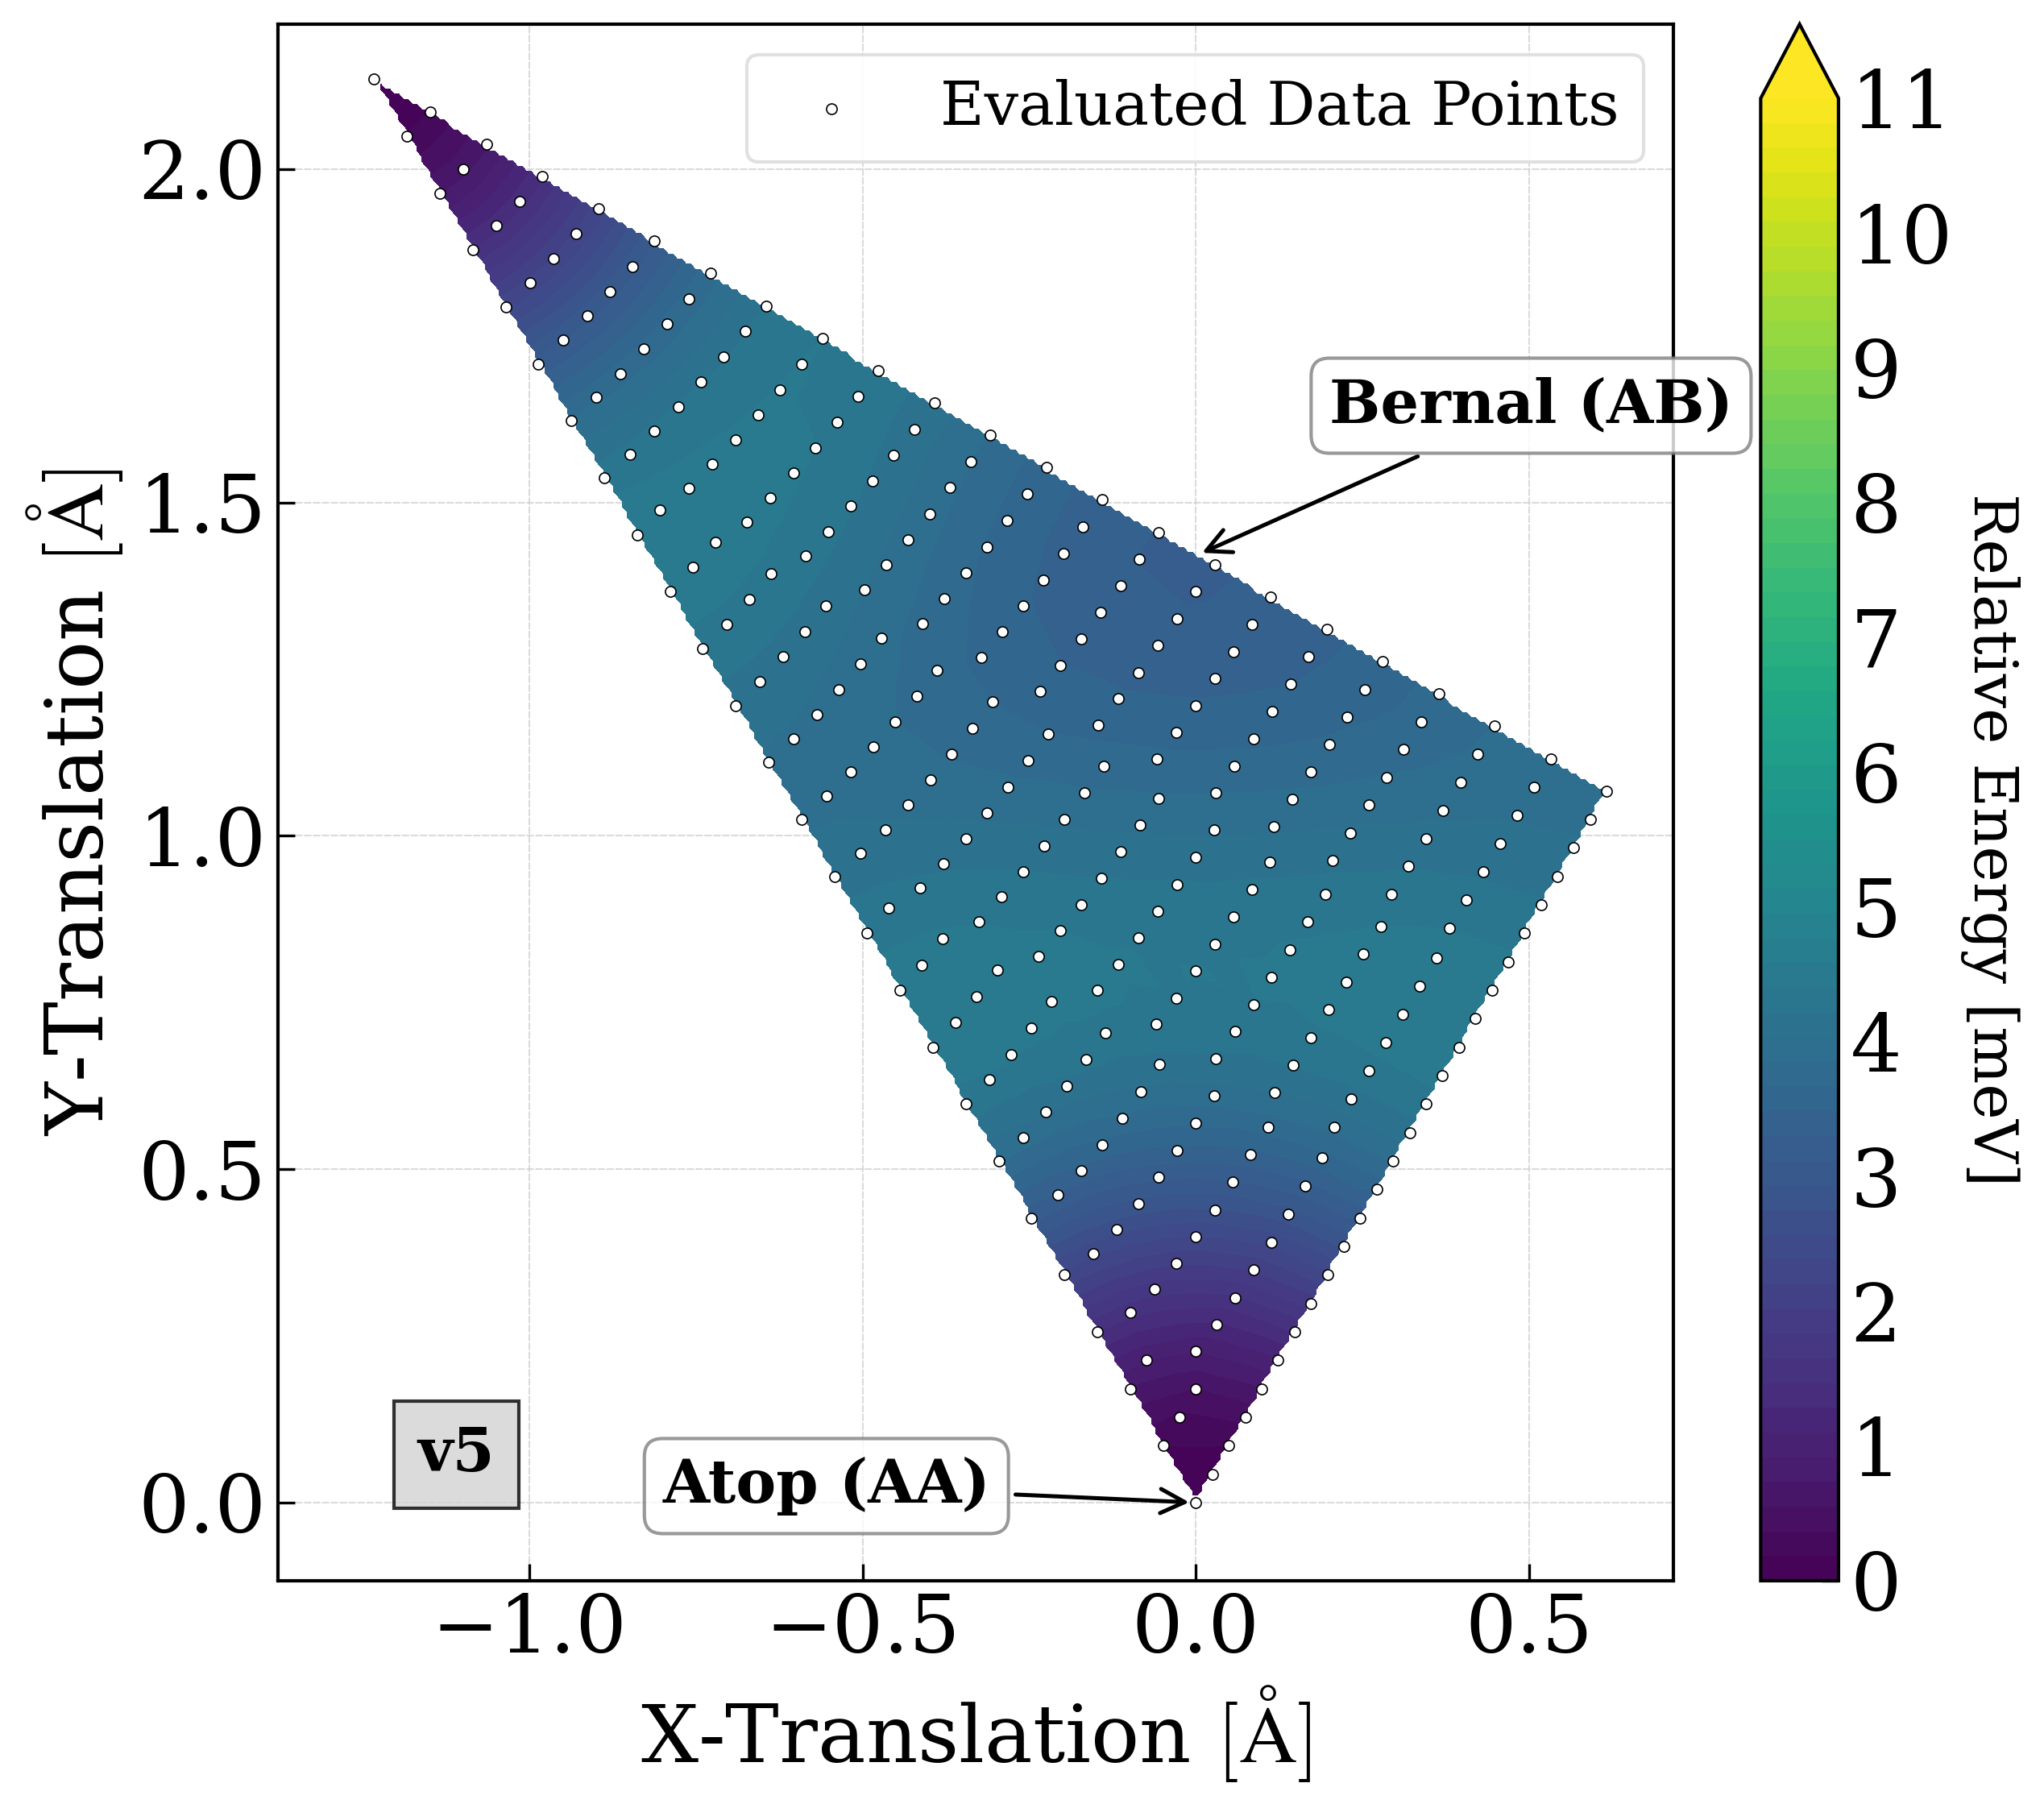

Success! Map rendering generated and saved to './plots/graphene_potential_map_v5.pdf'


In [14]:
for d, n in zip(dirs, names):
    plot(d, n)